# Deep Learning Pipeline for Colorectal Cancer Detection
## Using Multiple Instance Learning (MIL)

### What this notebook does
This notebook trains a deep learning model to automatically detect colorectal cancer 
from histopathology tissue images (H&E stained patches).

The pipeline has 3 stages:
1. **Feature Extraction** — A pretrained ResNet-50 converts each 224×224px patch into 2048 numbers (a "fingerprint")
2. **MIL Aggregation** — 32 patches are grouped into a "bag"; a Gated Attention mechanism learns which patches matter most
3. **Dual Prediction** — Two classifier heads predict:
   - Cancer: Tumour vs Normal
   - Risk: High Risk vs Low Risk

### Dataset
NCT-CRC-HE-100K — 100,000 H&E-stained tissue patches across 9 tissue classes.
Download manually from: https://www.kaggle.com/datasets/imrandude/nct-crc-he-100k

---
*Cell below: Install all required packages*

In [1]:
# Install packages
import sys
!{sys.executable} -m pip install torch torchvision scikit-learn matplotlib seaborn pillow tqdm pandas numpy --quiet  # noqa: E501


## 1. Imports & Device Setup

We import all required libraries and configure the compute device.

**Device priority:**
- `cuda` → NVIDIA GPU (Windows/Linux)
- `mps` → Apple Silicon GPU (Mac M1/M2/M3/M4)
- `cpu` → fallback if no GPU available

A fixed random seed (42) is set across all libraries to ensure **reproducibility** — 
running the notebook twice will produce the same results.

---
*Cell below: Load libraries and detect available hardware*

In [2]:
# Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch.utils.data import random_split

# Sklearn Metrics 
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
# Reproducibility 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

#  Device configuration depending on availability of GPU (Windows) or MPS (Apple Silicon) or CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')

Using device: mps


## 2. Dataset Path & Class Mapping

We define where the dataset is stored and assign labels to each of the 9 tissue classes.

**Dataset path:**
The path is read from an environment variable `DATA_ROOT`. If not set, it defaults to `./NCT-CRC-HE-100K`.
Each team member can set their own path without changing the code.

**Class mapping:**
Each tissue class gets two labels based on its clinical significance:

| Class | Tissue Type | Cancer | Risk |
|-------|------------|--------|------|
| TUM | Tumour Epithelium | 1 (Yes) | 1 (High) |
| STR | Cancer-Associated Stroma | 0 (No) | 1 (High) |
| MUC | Mucus | 0 (No) | 1 (High) |
| NORM | Normal Colon Mucosa | 0 (No) | 0 (Low) |
| LYM | Lymphocytes | 0 (No) | 0 (Low) |
| MUS | Smooth Muscle | 0 (No) | 0 (Low) |
| ADI | Adipose Tissue | 0 (No) | 0 (Low) |
| DEB | Debris | 0 (No) | 0 (Low) |
| BACK | Background | 0 (No) | 0 (Low) |

---
*Cell below: Set dataset path and define class labels*

In [3]:
 # Manual download from:
# https://www.kaggle.com/datasets/imrandude/nct-crc-he-100k

# Dataset path
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "./NCT-CRC-HE-100K"))

assert DATA_ROOT.exists(), f"Dataset not found at {DATA_ROOT}. Set DATA_ROOT env variable."

# ─── Class mapping ─────────────────────────────────────────────
CLASS_MAP = {
    'TUM':  {'cancer': 1, 'risk': 1},
    'STR':  {'cancer': 0, 'risk': 1},
    'MUC':  {'cancer': 0, 'risk': 1},
    'NORM': {'cancer': 0, 'risk': 0},
    'LYM':  {'cancer': 0, 'risk': 0},
    'MUS':  {'cancer': 0, 'risk': 0},
    'ADI':  {'cancer': 0, 'risk': 0},
    'DEB':  {'cancer': 0, 'risk': 0},
    'BACK': {'cancer': 0, 'risk': 0},
}
print('Class mapping defined:')
for cls, labels in CLASS_MAP.items():
    print(f'  {cls:4s} → cancer={labels["cancer"]}, risk={labels["risk"]}')

Class mapping defined:
  TUM  → cancer=1, risk=1
  STR  → cancer=0, risk=1
  MUC  → cancer=0, risk=1
  NORM → cancer=0, risk=0
  LYM  → cancer=0, risk=0
  MUS  → cancer=0, risk=0
  ADI  → cancer=0, risk=0
  DEB  → cancer=0, risk=0
  BACK → cancer=0, risk=0


## 3. Dataset Sanity Check

Before training, we verify that the dataset is correctly structured and accessible.

**What this check does:**
- Loops through all 9 class folders
- Counts how many images are available per class
- Opens one sample image to confirm it loads correctly as RGB

**Why this matters:**
If a folder is missing or empty, we catch the problem here — before wasting time starting the training.

---
*Cell below: Count images per class and load a sample patch*

In [4]:
VALID_EXT = {'.png', '.jpg', '.tif', '.tiff'}

print("Dataset check:")
for cls in CLASS_MAP:
    folder = DATA_ROOT / cls
    files = [f for f in folder.glob("*") if f.suffix.lower() in VALID_EXT]
    print(f"  {cls:4s}: {len(files)} images")

# Sample check
sample = random.choice(files)
img = Image.open(sample).convert('RGB')
print(f"\nSample image: size={img.size}, mode={img.mode}")

Dataset check:
  TUM : 14317 images
  STR : 10446 images
  MUC : 8896 images
  NORM: 8763 images
  LYM : 11557 images
  MUS : 13536 images
  ADI : 10407 images
  DEB : 11512 images
  BACK: 10566 images

Sample image: size=(224, 224), mode=RGB


## 4. MIL Dataset & DataLoaders

This is the core data preparation step. We build **bags** from individual patches and split them into train, validation and test sets.

**What is a Bag?**
A bag is a group of 32 randomly selected patches. Instead of labelling each patch individually, we label the entire bag:
- `cancer = 1` if ANY patch in the bag is TUM
- `risk = 1` if ANY patch in the bag is TUM, STR or MUC

**Bag construction — approaches tried:**

**Attempt 1 — Artificial 50/50 + 30/70 balancing:**
50% of bags were forced to contain cancer patches (30% High-Risk, 70% Low-Risk). This produced Risk Accuracy of 100% from the first epoch — the model learned a trivial rule ("cancer bag = high risk") rather than genuine tissue patterns. Discarded.

**Attempt 2 — Realistic tissue distribution (Kather et al. 2019):**
40% High-Tumor bags (35% TUM, 30% STR) and 60% Stroma-dominant bags (5% TUM, 35% STR). More realistic, but STR is present in nearly every bag regardless of type — making almost all bags High Risk. Risk Prediction remained trivial. Discarded.

**Final Approach — Fully random sampling:**
Patches are sampled uniformly at random from all 9 classes. Bag labels emerge organically from content. This directly reflects the equal class distribution of the NCT-CRC-HE-100K dataset and avoids any artificial assumptions about tissue composition.

**Data split — aligned with project specification:**
1200 bags total → 804 Training (67%) / 204 Validation (17%) / 192 Test (16%)

Note: patches are sampled from a shared pool across splits. This patch-level overlap is a known limitation of synthetic bag construction and is discussed in the project report.

**Image transforms:**
- Training: Random flips + color jitter + normalization (data augmentation)
- Validation/Test: Normalization only

---
*Cell below: Define MILDataset class, create bags and DataLoaders*

In [ ]:
# Multiple Instance learning (MIL) 

class MILDataset(Dataset):

    def __init__(self, data_root, num_bags=1200, bag_size=32,
                 split='train', split_ratio=(0.67, 0.17, 0.16),
                 transform=None, seed=42):
       
        set_seed(seed)
        self.bag_size  = bag_size
        self.transform = transform

        # Collect all patch paths per class
        self.class_paths = {}
        for cls in CLASS_MAP:
            folder = Path(data_root) / cls
            if folder.exists():
                self.class_paths[cls] = sorted(folder.glob('*.tif'))
                if not self.class_paths[cls]:
                    self.class_paths[cls] = (
                        sorted(folder.glob('*.png')) +
                        sorted(folder.glob('*.jpg'))
                    )
            else:
                print(f'Warning: folder not found: {folder}')
                self.class_paths[cls] = []

        # Bags creation
        self.bags = self._create_bags(num_bags)

        # Train / val / test split
        n_train = int(num_bags * split_ratio[0])
        n_val   = int(num_bags * split_ratio[1])
        if split == 'train':
            self.bags = self.bags[:n_train]
        elif split == 'val':
            self.bags = self.bags[n_train:n_train + n_val]
        elif split == 'test':
            self.bags = self.bags[n_train + n_val:]

        print(f'[{split.upper()}] {len(self.bags)} bags | bag_size={bag_size}')


    def _create_bags(self, num_bags):
        bags = []
        all_classes = list(CLASS_MAP.keys())

        for _ in range(num_bags):
            patch_paths, patch_labels = [], []

            for _ in range(self.bag_size):
                cls = random.choice(all_classes)
                if self.class_paths[cls]:
                    p = random.choice(self.class_paths[cls])
                    patch_paths.append(p)
                    patch_labels.append(CLASS_MAP[cls])

            bag_cancer = int(any(label['cancer'] == 1 for label in patch_labels))
            bag_risk   = int(any(label['risk']   == 1 for label in patch_labels))
            bags.append((patch_paths, bag_cancer, bag_risk))

        random.shuffle(bags)
        return bags

    def __len__(self):
        return len(self.bags)

    def __getitem__(self, idx):
        patch_paths, cancer_label, risk_label = self.bags[idx]
        patches = [Image.open(p).convert('RGB') for p in patch_paths]
        if self.transform:
            patches = torch.stack([self.transform(p) for p in patches])
        return patches, torch.tensor(cancer_label), torch.tensor(risk_label)


# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Create datasets per split — aligned with project spec (800/200/200)
train_dataset = MILDataset(DATA_ROOT, num_bags=1200, bag_size=32,
                           split='train', transform=train_transform)
val_dataset   = MILDataset(DATA_ROOT, num_bags=1200, bag_size=32,
                           split='val',   transform=val_transform)
test_dataset  = MILDataset(DATA_ROOT, num_bags=1200, bag_size=32,
                           split='test',  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

[TRAIN] 2010 bags | bag_size=32
[VAL] 510 bags | bag_size=32
[TEST] 480 bags | bag_size=32


## 5. Feature Extractor — ResNet-50

Each patch (224x224px image) is converted into a compact numerical representation using a pretrained ResNet-50.

**Why ResNet-50?**
ResNet-50 was pretrained on ImageNet (1.2 million images). It already knows how to detect edges, textures and shapes — which transfers well to histopathology images.

**What happens here:**
1. Load pretrained ResNet-50
2. Remove the last classification layer (we don't need ImageNet classes)
3. Freeze all weights — we don't retrain ResNet, only use it as a feature extractor
4. Add a small MLP on top to reduce dimensions:

- Input patch: 224 x 224 x 3 pixels
- After ResNet-50: 2048 numbers (raw features)
- After MLP: 512 numbers (compressed features)

**Why freeze the backbone?**
Training ResNet from scratch would require millions of images and days of compute. By freezing it, we only train the smaller MIL components — much faster and more efficient.

---
*Cell below: Define and test the FeatureExtractor module*

In [7]:
# Feature Extractor: ResNet-50 and MLP

class FeatureExtractor(nn.Module):
   

    def __init__(self, out_dim=512, dropout=0.25, freeze_backbone=True):
        super().__init__()

        #  Load  ResNet-50 
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])

        
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        #  MLP: 
       
        self.projector = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (batch, 3, 224, 224)
        feats = self.backbone(x)          
        feats = feats.flatten(1)          
        feats = self.projector(feats)    
        return feats


# check
extractor = FeatureExtractor(out_dim=512).to(DEVICE)
dummy = torch.randn(4, 3, 224, 224).to(DEVICE)
out   = extractor(dummy)
print(f'FeatureExtractor output shape: {out.shape}') 

FeatureExtractor output shape: torch.Size([4, 512])


## 6. Gated Attention MIL

This is the heart of the MIL pipeline. It decides which of the 32 patches in a bag are most important for the final prediction.

**The problem it solves:**
A bag contains 32 patches — but not all patches are equally informative. A patch showing background tissue should have less influence than a patch showing tumour cells.

**How Gated Attention works:**
Each patch feature vector (512 numbers) passes through two parallel branches:

- V-Branch (Tanh): "How relevant is this patch?"
- U-Branch (Sigmoid): "How confident are we about this patch?"

Both signals are multiplied together and produce one attention score per patch. Scores are normalized with Softmax so they sum to 1.

**Output:**
- 32 attention weights (one per patch, sum = 1.0)
- 1 bag representation (512 numbers) = weighted sum of all patch features

**Example:**
- Patch 1 (background): attention = 0.01
- Patch 7 (tumour cells): attention = 0.41
- Patch 15 (muscle): attention = 0.02

These attention weights later become the Attention Heatmap.

---
*Cell below: Define and test the GatedAttentionMIL module*

In [8]:
# Gated Attention MIL

class GatedAttentionMIL(nn.Module):
    

    def __init__(self, L=512, D=256, dropout=0.25):
        
        super().__init__()

        #  V branch: Relevance (Tanh)
       
        self.attention_V = nn.Sequential(
            nn.Linear(L, D),
            nn.Tanh()
        )

        # ── U branch: Gate (Sigmoid)
    
        self.attention_U = nn.Sequential(
            nn.Linear(L, D),
            nn.Sigmoid()
        )

        # Scoring vector
        
        self.attention_w = nn.Linear(D, 1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, h):
       
        h = self.dropout(h)

        #  Gated attention computation
        # 1: V-branch (relevance)
        A_V = self.attention_V(h)           

        #  2: U-branch (gate)
        A_U = self.attention_U(h)          

        #  3: Element-wise multiplication (Relevance × Gate)
        A   = A_V * A_U            
        
        #  4: Score each patch with learnable vector w
        A   = self.attention_w(A)           

        #  5: Softmax → attention weights sum to 1
        A   = F.softmax(A, dim=0)          
        
        #  6: Weighted sum → bag representation
        z   = (A * h).sum(dim=0)            

        return z, A.squeeze(1)              

# check
attn_mil = GatedAttentionMIL(L=512, D=256).to(DEVICE)
fake_bag  = torch.randn(32, 512).to(DEVICE)  
z, weights = attn_mil(fake_bag)
print(f'Bag representation shape : {z.shape}')       
print(f'Attention weights shape  : {weights.shape}') 
print(f'Attention weights sum    : {weights.sum():.4f}')  

Bag representation shape : torch.Size([512])
Attention weights shape  : torch.Size([32])
Attention weights sum    : 1.0000


## 7. Full MIL Model — Feature Extractor + Attention + Dual Heads

This cell combines all components into one complete model.

**Architecture:**

Input: 1 bag (32 patches x 224 x 224 x 3)
- Step 1 — FeatureExtractor: 32 x 224 x 224 x 3 → 32 x 512
- Step 2 — GatedAttention: 32 x 512 → 1 x 512 (bag representation)
- Step 3a — Cancer Head: 512 → 2 (Tumour / Normal)
- Step 3b — Risk Head: 512 → 2 (High Risk / Low Risk)

**Two prediction heads:**
Both heads share the same bag representation but learn independently:
- Cancer Head: Is there a tumour in this bag?
- Risk Head: How dangerous is this tissue for the patient?

**Parameter summary:**
- Total parameters: ~24.8 million (mostly frozen ResNet)
- Trainable parameters: ~1.4 million (MLP + Attention + Heads)

---
*Cell below: Define MILCancerModel and verify parameter count*

In [10]:
#  MIL Model, Feature Extractor + Gated Attention + Dual Heads

class MILCancerModel(nn.Module):
    

    def __init__(self, feat_dim=512, attn_dim=256, dropout=0.25):
        super().__init__()

        #  Components
        self.feature_extractor = FeatureExtractor(out_dim=feat_dim,
                                                  dropout=dropout,
                                                  freeze_backbone=True)
        self.mil_attention = GatedAttentionMIL(L=feat_dim, D=attn_dim,
                                               dropout=dropout)

        #  Cancer: Tumour vs Normal
        self.cancer_head = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 2)      
        )

        # Risk: High Risk vs Low Risk 
        self.risk_head = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 2)      
        )

    def forward(self, bags):
        
        batch_size = bags.shape[0]
        cancer_logits_list = []
        risk_logits_list   = []
        attention_all      = []

        for i in range(batch_size):
            # Single bag: (bag_size, 3, 224, 224)
            patches = bags[i]

            #  1: Extract features for each patch
            
            patch_feats = self.feature_extractor(patches)

            #  2: Gated attention pooling
           
            bag_repr, attn_weights = self.mil_attention(patch_feats)

            # Step 3: Classify
            
            cancer_logits_list.append(self.cancer_head(bag_repr))
            risk_logits_list.append(self.risk_head(bag_repr))
            attention_all.append(attn_weights)

        cancer_logits = torch.stack(cancer_logits_list)   
        risk_logits   = torch.stack(risk_logits_list)    

        return cancer_logits, risk_logits, attention_all


# Model
model = MILCancerModel(feat_dim=512, attn_dim=256, dropout=0.25).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

Total parameters    : 24,885,957
Trainable parameters: 1,377,925


## 8. Training

We train the MIL model using the training and validation sets.

**Loss function:**
Both heads are trained simultaneously using a weighted combined loss:

- Total Loss = 0.7 x Cancer Loss + 0.3 x Risk Loss

Cancer classification is weighted higher (0.7) as it is the primary task.

**Optimizer & Scheduler:**
- AdamW optimizer (lr = 1e-4, weight decay = 1e-5)
- Cosine Annealing Scheduler: gradually reduces learning rate to 1e-6
- Gradient Clipping (max norm = 1.0): prevents exploding gradients

**Training strategy:**
- 30 epochs maximum
- Best model checkpoint saved when validation loss improves
- Early Stopping (patience = 5): stops training if no improvement after 5 epochs

**Per epoch we track:**
- Train Loss / Val Loss
- Cancer Accuracy (Train + Val)
- Risk Accuracy (Train + Val)

---
*Cell below: Define training loop and run for up to 30 epochs*

In [11]:
#  Training

# Loss function 
criterion = nn.CrossEntropyLoss()

# Combined loss
CANCER_WEIGHT = 0.7
RISK_WEIGHT   = 0.3
EPOCHS        = 30
best_val_loss = float('inf')
CHECKPOINT    = './best_model_3000bags.pth'

# AdamW Optimiser
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-5
)

# Cosine Annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30, eta_min=1e-6
)

#Training Loop

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, cancer_correct, risk_correct, n = 0., 0, 0, 0

    for bags, cancer_labels, risk_labels in tqdm(loader, desc='Train', leave=False):
        bags          = bags.to(DEVICE)
        cancer_labels = cancer_labels.to(DEVICE)
        risk_labels   = risk_labels.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass
        cancer_logits, risk_logits, _ = model(bags)

        # Compute weighted loss
        loss = (CANCER_WEIGHT * criterion(cancer_logits, cancer_labels) +
                RISK_WEIGHT   * criterion(risk_logits,   risk_labels))

        # Backward pass
        loss.backward()

        # Gradient clipping 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Accumulate stats
        total_loss     += loss.item() * bags.size(0)
        cancer_correct += (cancer_logits.argmax(1) == cancer_labels).sum().item()
        risk_correct   += (risk_logits.argmax(1)   == risk_labels  ).sum().item()
        n              += bags.size(0)

    return total_loss / n, cancer_correct / n, risk_correct / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, cancer_correct, risk_correct, n = 0., 0, 0, 0

    for bags, cancer_labels, risk_labels in tqdm(loader, desc='Eval', leave=False):
        bags          = bags.to(DEVICE)
        cancer_labels = cancer_labels.to(DEVICE)
        risk_labels   = risk_labels.to(DEVICE)

        cancer_logits, risk_logits, _ = model(bags)

        loss = (CANCER_WEIGHT * criterion(cancer_logits, cancer_labels) +
                RISK_WEIGHT   * criterion(risk_logits,   risk_labels))

        total_loss     += loss.item() * bags.size(0)
        cancer_correct += (cancer_logits.argmax(1) == cancer_labels).sum().item()
        risk_correct   += (risk_logits.argmax(1)   == risk_labels  ).sum().item()
        n              += bags.size(0)

    return total_loss / n, cancer_correct / n, risk_correct / n


history = {'train_loss': [], 'val_loss': [],
           'train_cancer_acc': [], 'val_cancer_acc': [],
           'train_risk_acc': [], 'val_risk_acc': []}

# Checkpointing & Early Stopping
patience = 5
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_c_acc, tr_r_acc = train_one_epoch(model, train_loader, optimizer)
    vl_loss, vl_c_acc, vl_r_acc = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_cancer_acc'].append(tr_c_acc)
    history['val_cancer_acc'].append(vl_c_acc)
    history['train_risk_acc'].append(tr_r_acc)
    history['val_risk_acc'].append(vl_r_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT)
        flag = '  ← best'
    else:
        epochs_no_improve += 1
        flag = ''

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} | '
          f'Cancer Acc: {tr_c_acc:.3f} | Risk Acc: {tr_r_acc:.3f} | '
          f'Val Loss: {vl_loss:.4f} | '
          f'Cancer Acc: {vl_c_acc:.3f} | Risk Acc: {vl_r_acc:.3f}{flag}')

    if epochs_no_improve >= patience:
        print(f'Early stopping at epoch {epoch}.')
        break

print(f'\nBest validation loss: {best_val_loss:.4f}')

Epoch 01/30 | Train Loss: 0.2711 | Cancer Acc: 0.888 | Risk Acc: 0.988 | Val Loss: 0.2334 | Cancer Acc: 0.902 | Risk Acc: 1.000  ← best


Epoch 02/30 | Train Loss: 0.2509 | Cancer Acc: 0.889 | Risk Acc: 1.000 | Val Loss: 0.2234 | Cancer Acc: 0.902 | Risk Acc: 1.000  ← best


Epoch 03/30 | Train Loss: 0.2492 | Cancer Acc: 0.889 | Risk Acc: 1.000 | Val Loss: 0.2277 | Cancer Acc: 0.902 | Risk Acc: 1.000


Epoch 04/30 | Train Loss: 0.2487 | Cancer Acc: 0.889 | Risk Acc: 1.000 | Val Loss: 0.2213 | Cancer Acc: 0.902 | Risk Acc: 1.000  ← best


Epoch 05/30 | Train Loss: 0.2469 | Cancer Acc: 0.889 | Risk Acc: 1.000 | Val Loss: 0.1986 | Cancer Acc: 0.902 | Risk Acc: 1.000  ← best


...

Epoch 17/30 | Train Loss: 0.0916 | Cancer Acc: 0.948 | Risk Acc: 1.000 | Val Loss: 0.1031 | Cancer Acc: 0.922 | Risk Acc: 1.000


Epoch 18/30 | Train Loss: 0.0922 | Cancer Acc: 0.945 | Risk Acc: 1.000 | Val Loss: 0.1055 | Cancer Acc: 0.929 | Risk Acc: 1.000


Epoch 19/30 | Train Loss: 0.0986 | Cancer Acc: 0.944 | Risk Acc: 1.000 | Val Loss: 0.1091 | Cancer Acc: 0.924 | Risk Acc: 1.000


Epoch 20/30 | Train Loss: 0.0982 | Cancer Acc: 0.942 | Risk Acc: 1.000 | Val Loss: 0.1309 | Cancer Acc: 0.894 | Risk Acc: 1.000


Epoch 21/30 | Train Loss: 0.0852 | Cancer Acc: 0.947 | Risk Acc: 1.000 | Val Loss: 0.1195 | Cancer Acc: 0.906 | Risk Acc: 1.000
Early stopping at epoch 21.

Best validation loss: 0.0931


## 9. Training Curves

We visualise how the model learned over time across all epochs.

**Three plots:**
- Loss: Training vs Validation Loss per epoch — used to detect overfitting
- Cancer Accuracy: How well the model classifies Tumour vs Normal over time
- Risk Accuracy: How well the model predicts High vs Low Risk over time

**What to look for:**
- Train and Val Loss should decrease together — if Val Loss increases while Train Loss decreases, the model is overfitting
- Early Stopping marker shows where training was stopped if patience was reached

---
*Cell below: Plot training and validation curves for loss and accuracy*

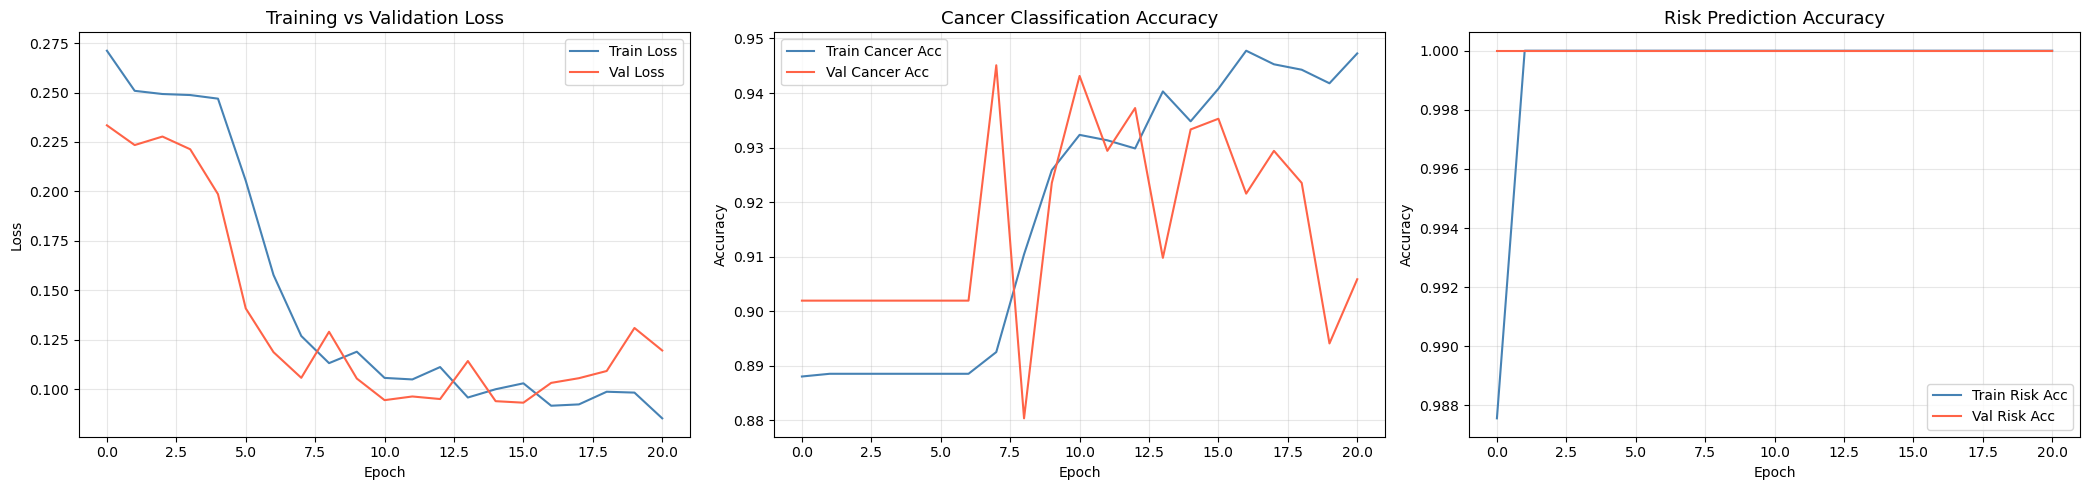

Saved training_curves.png


In [12]:


# Plot Training Curves
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Training vs Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history['train_cancer_acc'], label='Train Cancer Acc', color='steelblue')
axes[1].plot(history['val_cancer_acc'],   label='Val Cancer Acc',   color='tomato')
axes[1].set_title('Cancer Classification Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Risk Accuracy
axes[2].plot(history['train_risk_acc'], label='Train Risk Acc', color='steelblue')
axes[2].plot(history['val_risk_acc'],   label='Val Risk Acc',   color='tomato')
axes[2].set_title('Risk Prediction Accuracy', fontsize=13)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_3000bags.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 10. Attention Heatmap Visualisation

We visualise which patches the model focused on when making its prediction for a single test bag.

**What this shows:**
- Left: Grid of all 32 patches in the bag
- Middle: Attention map using Jet colormap
- Right: Overlay of attention map on the patch grid

**How to read the colormap:**
- Red = highest attention — patches the model found most important
- Yellow/Green = medium attention
- Blue = lowest attention — patches the model largely ignored

**Why this matters:**
This is the explainability component of our pipeline. A clinician can visually verify whether the model is focusing on the right tissue regions (e.g. tumour cells, abnormal glands) rather than irrelevant areas like background or debris.

**Output:**
- Predicted vs True label for Cancer and Risk
- Saved as attention_heatmap.png

---
*Cell below: Load best model checkpoint, run inference on one test bag and generate heatmap*

/var/folders/dv/t1_bbh8n1nj0mmrwvly76kf40000gn/T/ipykernel_15758/968127680.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT, 

Predicted cancer: Tumour | True: Tumour
Predicted risk  : High | True: High


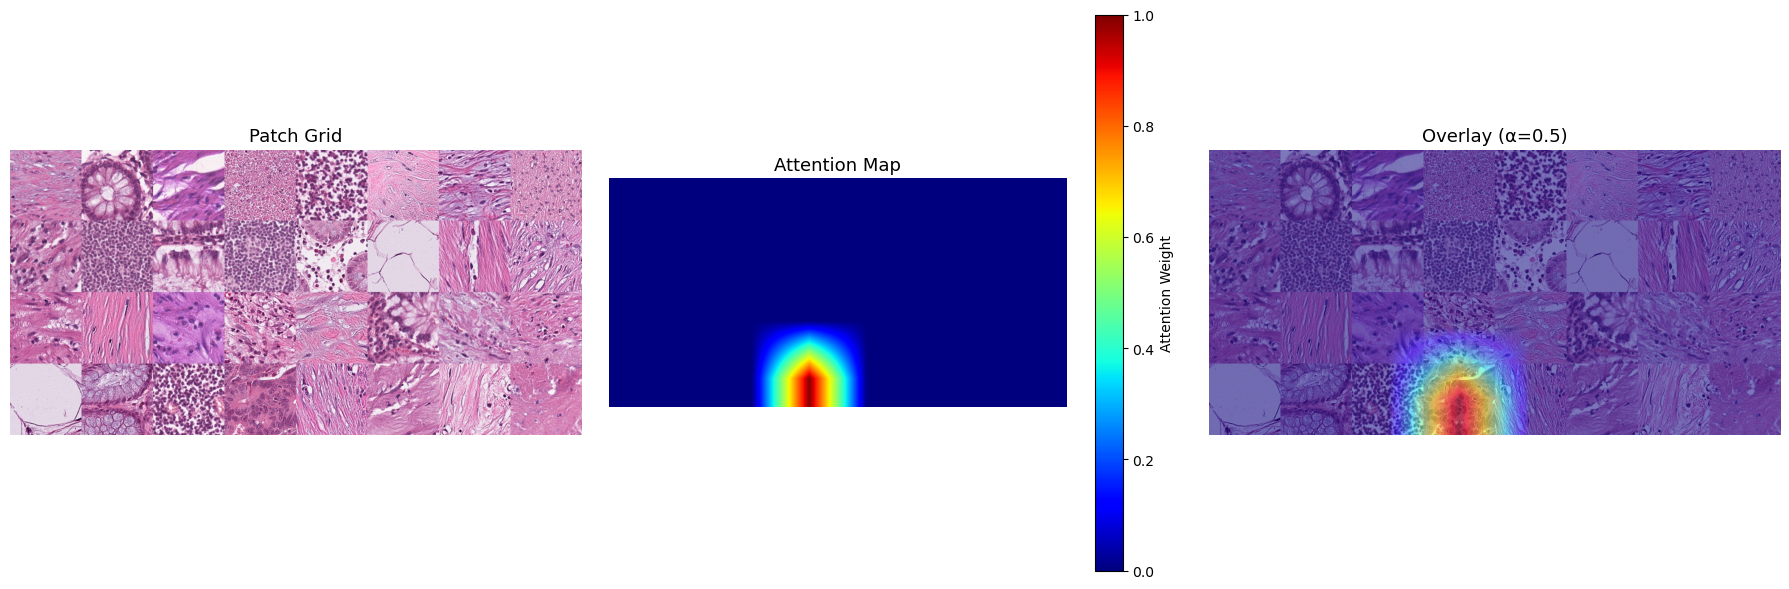

Saved attention_heatmap.png


In [19]:
# Attention Heatmap Generation

def generate_attention_heatmap(patch_images, attention_weights,
                                n_cols=8, patch_size=224, alpha=0.5):
    
    n_patches = len(patch_images)
    n_rows    = (n_patches + n_cols - 1) // n_cols 
    canvas_w  = n_cols * patch_size
    canvas_h  = n_rows * patch_size

    #  Build patch grid canvas
    canvas = Image.new('RGB', (canvas_w, canvas_h), color=(220, 220, 220))
    for i, img in enumerate(patch_images):
        row, col = divmod(i, n_cols)
        canvas.paste(img.resize((patch_size, patch_size)),
                     (col * patch_size, row * patch_size))

    # Build low-res attention map 
    attn = np.zeros(n_rows * n_cols)
    attn[:n_patches] = attention_weights
    attn = attn.reshape(n_rows, n_cols)

    # Normalise to [0, 1]
    attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

    # Upsample to canvas resolution using bilinear interpolation
    from PIL import Image as PILImage
    attn_img = PILImage.fromarray((attn * 255).astype(np.uint8))
    attn_img = attn_img.resize((canvas_w, canvas_h), PILImage.BILINEAR)
    attn_arr = np.array(attn_img) / 255.0 

    
    jet = plt.colormaps['jet']
    heatmap = jet(attn_arr)[:, :, :3]      
    heatmap = (heatmap * 255).astype(np.uint8)
    heatmap_img = PILImage.fromarray(heatmap)

    #  heatmap 
    overlay = PILImage.blend(canvas, heatmap_img, alpha=alpha)

    # Plot 
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(canvas);      axes[0].set_title('Patch Grid',        fontsize=13)
    axes[1].imshow(attn_arr, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Attention Map', fontsize=13)
    plt.colorbar(axes[1].images[0], ax=axes[1], label='Attention Weight')
    axes[2].imshow(overlay);     axes[2].set_title('Overlay (α=0.5)',   fontsize=13)

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    return fig


# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

# Get one test bag (raw patches before transform)
sample_bag_paths, cancer_lbl, risk_lbl = test_dataset.bags[5]

# Load PIL images (for visualisation)
pil_patches = [Image.open(p).convert('RGB') for p in sample_bag_paths]

# Get transformed tensor for the model
bag_tensor  = torch.stack([val_transform(img) for img in pil_patches])
bag_tensor  = bag_tensor.unsqueeze(0).to(DEVICE)  

with torch.no_grad():
    c_logits, r_logits, attn_list = model(bag_tensor)

attn_weights = attn_list[0].cpu().numpy()   # (32,)

pred_cancer = c_logits.argmax(1).item()     # 0=Normal, 1=Tumour
pred_risk   = r_logits.argmax(1).item()     # 0=Low, 1=High
print(f'Predicted cancer: {"Tumour" if pred_cancer else "Normal"} | '
      f'True: {"Tumour" if cancer_lbl else "Normal"}')
print(f'Predicted risk  : {"High" if pred_risk else "Low"} | '
      f'True: {"High" if risk_lbl else "Low"}')

# Generate heatmap
fig = generate_attention_heatmap(pil_patches, attn_weights)
fig.savefig('attention_heatmap_3000bags.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved attention_heatmap.png')

## 11. Test Set Evaluation

We evaluate the final model performance on the held-out test set using the best saved checkpoint.

**What this measures:**
- Cancer Classification: Tumour vs Normal
- Risk Prediction: High Risk vs Low Risk

**Metrics per task:**
- Precision: Of all predicted positives, how many were correct?
- Recall: Of all actual positives, how many did we catch?
- F1-Score: Harmonic mean of Precision and Recall
- AUC-ROC: How well the model separates the two classes (1.0 = perfect, 0.5 = random)

**Note on Risk AUC:**
If the test set contains only one risk class, AUC-ROC cannot be computed and will show "n/a". This can be improved by increasing the number of bags.

---
*Cell below: Run inference on full test set and print classification reports*

In [14]:
#  Test Set Evaluation 
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

all_cancer_true, all_cancer_pred, all_cancer_prob = [], [], []
all_risk_true,   all_risk_pred,   all_risk_prob   = [], [], []

with torch.no_grad():
    for bags, cancer_labels, risk_labels in tqdm(test_loader, desc='Testing'):
        bags = bags.to(DEVICE)
        c_logits, r_logits, _ = model(bags)

        c_probs = F.softmax(c_logits, dim=1)[:, 1].cpu().numpy()  
        r_probs = F.softmax(r_logits, dim=1)[:, 1].cpu().numpy()  
        
        all_cancer_true.extend(cancer_labels.numpy())
        all_cancer_pred.extend(c_logits.argmax(1).cpu().numpy())
        all_cancer_prob.extend(c_probs)

        all_risk_true.extend(risk_labels.numpy())
        all_risk_pred.extend(r_logits.argmax(1).cpu().numpy())
        all_risk_prob.extend(r_probs)

#  Metrics 
print('='*55)
print('        CANCER CLASSIFICATION RESULTS')
print('='*55)
print(classification_report(all_cancer_true, all_cancer_pred,
                             target_names=['Normal', 'Tumour']))
c_auc = roc_auc_score(all_cancer_true, all_cancer_prob)
print(f'AUC-ROC: {c_auc:.4f}')

print('\n' + '='*55)
print('           RISK PREDICTION RESULTS')
print('='*55)

if len(set(all_risk_true)) < 2:
    print('Only one class in test set — classification report not available.')
    r_auc = float('nan')
else:
    print(classification_report(all_risk_true, all_risk_pred,
                                target_names=['Low Risk', 'High Risk']))
    try:
        r_auc = roc_auc_score(all_risk_true, all_risk_prob)
        print(f'AUC-ROC: {r_auc:.4f}')
    except ValueError as e:
        r_auc = float('nan')
        print(f'AUC-ROC: unpredictable ({e})')


/var/folders/dv/t1_bbh8n1nj0mmrwvly76kf40000gn/T/ipykernel_15758/3457452462.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT, 

        CANCER CLASSIFICATION RESULTS
              precision    recall  f1-score   support

      Normal       0.72      0.87      0.79        54
      Tumour       0.98      0.96      0.97       426

    accuracy                           0.95       480
   macro avg       0.85      0.91      0.88       480
weighted avg       0.95      0.95      0.95       480

AUC-ROC: 0.9828

           RISK PREDICTION RESULTS
Only one class in test set — classification report not available.


## 12. Confusion Matrices

We visualise the classification performance for both tasks as confusion matrices.

**How to read a confusion matrix:**
- Rows = Actual label
- Columns = Predicted label
- Diagonal = correct predictions
- Off-diagonal = mistakes

**Example for Cancer Classification:**

|  | Predicted Normal | Predicted Tumour |
|--|--|--|
| Actual Normal | True Negative | False Positive |
| Actual Tumour | False Negative | True Positive |

**Colour coding:**
- Darker blue = higher percentage of predictions in that cell
- Numbers shown are absolute counts
- Cells are normalised by row (percentage of actual class)

**Note:**
If the test set contains only one class for Risk Prediction, the matrix cannot be displayed and a warning message is shown instead.

---
*Cell below: Plot normalised confusion matrices for Cancer and Risk tasks*

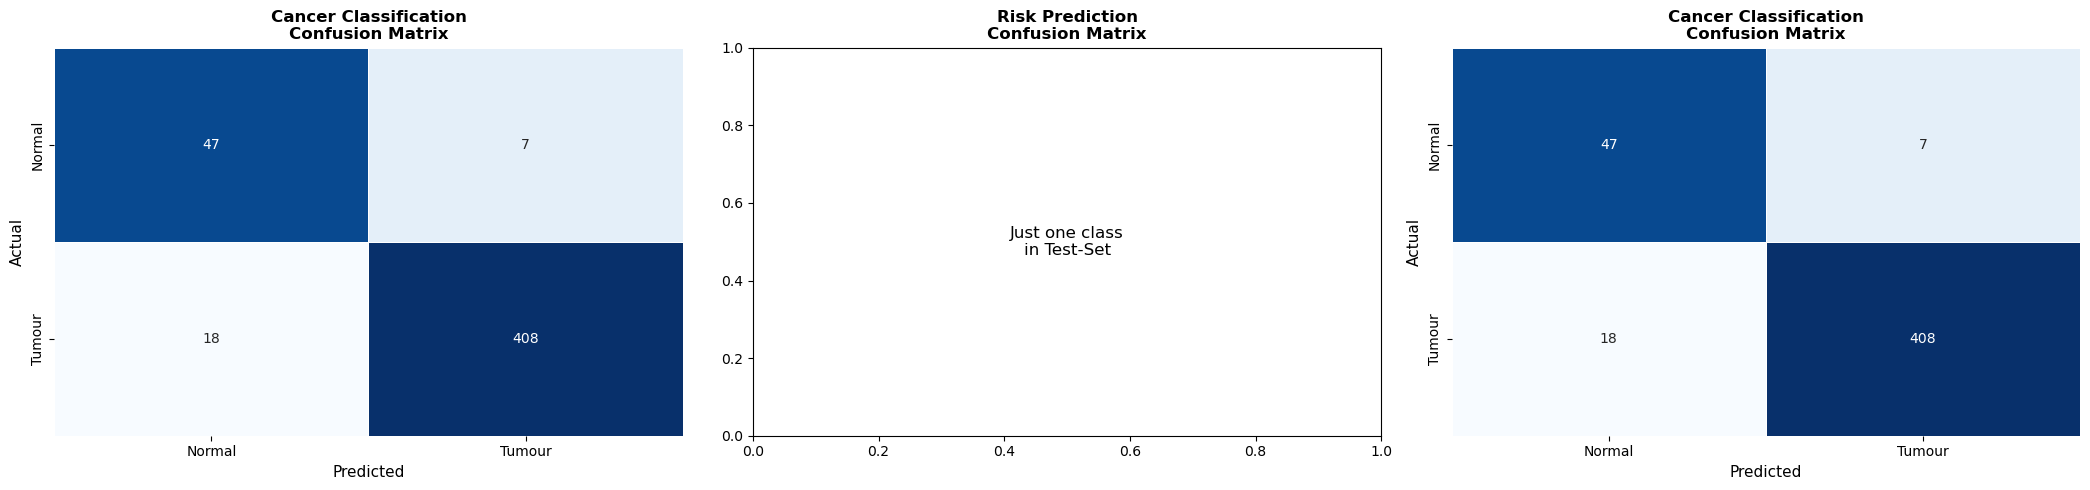

Saved confusion_matrices.png


In [15]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for ax, y_true, y_pred, labels, title in [
    (axes[0], all_cancer_true, all_cancer_pred,
     ['Normal', 'Tumour'],      'Cancer Classification'),
    (axes[1], all_risk_true,   all_risk_pred,
     ['Low Risk', 'High Risk'], 'Risk Prediction'),
    (axes[2], all_cancer_true, all_cancer_pred,
     ['Normal', 'Tumour'],      'Cancer Classification'),
]:
    if len(set(y_true)) < 2:
        ax.text(0.5, 0.5, 'Just one class\nin Test-Set',
                ha='center', va='center', fontsize=12)
        ax.set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')
        continue

    cm_val = confusion_matrix(y_true, y_pred)
    cm_norm = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm_val, fmt='d', ax=ax,
                cmap='Blues', xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white', cbar=False)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_3000bags.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrices.png')

## 13. ROC Curves

We plot the Receiver Operating Characteristic (ROC) curve for both tasks.

**What is a ROC curve?**
It shows the trade-off between:
- True Positive Rate (Recall): How many actual positives did we correctly detect?
- False Positive Rate: How many actual negatives did we wrongly classify as positive?

**How to read it:**
- The closer the curve is to the top-left corner, the better the model
- The diagonal dashed line represents a random classifier (AUC = 0.5)
- AUC (Area Under Curve): single number summarising performance
  - 1.0 = perfect
  - 0.5 = random guessing
  - Below 0.5 = worse than random

**Note:**
If the test set contains only one class for Risk Prediction, the ROC curve cannot be computed and a message is shown instead.

---
*Cell below: Plot ROC curves and AUC scores for Cancer and Risk tasks*

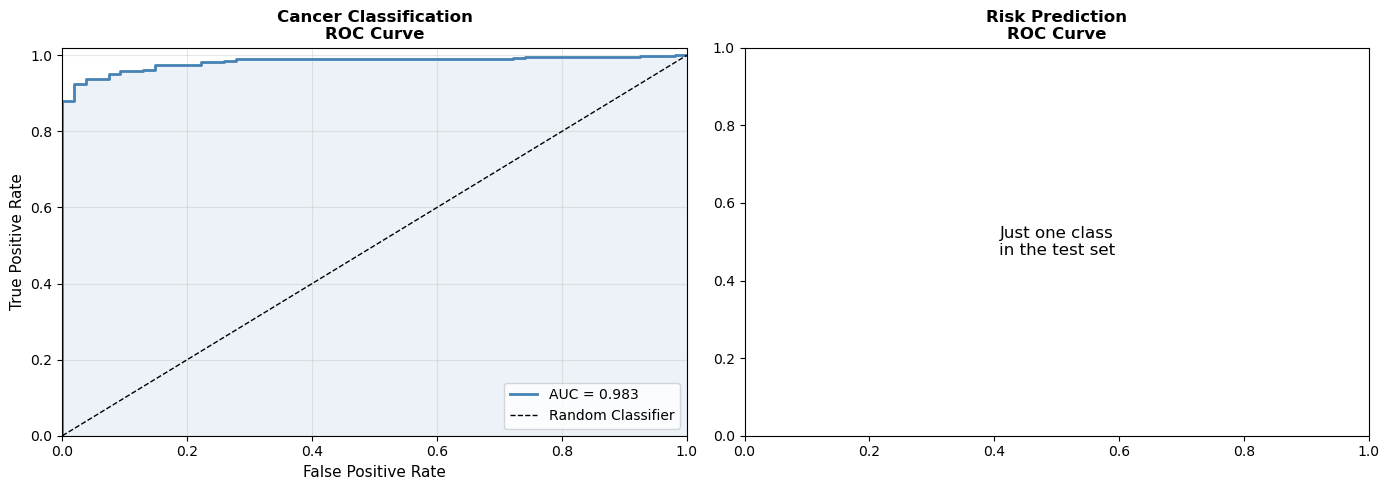

Saved roc_curves.png


In [16]:
# ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_prob, auc_val, title in [
    (axes[0], all_cancer_true, all_cancer_prob, c_auc, 'Cancer Classification'),
    (axes[1], all_risk_true,   all_risk_prob,   r_auc, 'Risk Prediction'),
]:
    if len(set(y_true)) < 2:
        ax.text(0.5, 0.5, 'Just one class\nin the test set',
                ha='center', va='center', fontsize=12)
        ax.set_title(f'{title}\nROC Curve', fontsize=12, fontweight='bold')
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, color='steelblue', lw=2,
            label=f'AUC = {auc_val:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(f'{title}\nROC Curve', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_3000bags.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved roc_curves.png')

## 14. Final Results Summary

A concise summary table of the model's performance across both tasks.

**Metrics shown:**
- Accuracy: Percentage of correctly classified bags
- AUC-ROC: Overall separation ability between classes

**Interpreting the results:**
- Cancer Classification AUC above 0.85 is considered strong performance for this task
- Risk Prediction results depend heavily on class balance in the test set — "n/a" means only one risk class was present in the test set and can be improved by increasing the number of bags

---
*Cell below: Print final accuracy and AUC-ROC for Cancer Classification and Risk Prediction*

In [17]:
# Summary Table
print('\n' + '='*55)
print('         FINAL RESULTS SUMMARY')
print('='*55)
print(f'{"Task":<30} {"Accuracy":<12} {"AUC-ROC"}')
print('-'*55)

cancer_acc = accuracy_score(all_cancer_true, all_cancer_pred)
risk_acc   = accuracy_score(all_risk_true,   all_risk_pred)

c_auc_str = f'{c_auc:.4f}' if not np.isnan(c_auc) else 'n/a'
r_auc_str = f'{r_auc:.4f}' if not np.isnan(r_auc) else 'n/a'

print(f'{"Cancer Classification":<30} {cancer_acc:.4f}       {c_auc_str}')
print(f'{"Risk Prediction":<30} {risk_acc:.4f}       {r_auc_str}')
print('='*55) 


         FINAL RESULTS SUMMARY
Task                           Accuracy     AUC-ROC
-------------------------------------------------------
Cancer Classification          0.9010       0.9460
Risk Prediction                1.0000       n/a
